# Experiment — Explainability: feature importance

**Category:** explainability

Explain the saved best model with permutation importance (model-agnostic) and, when available, native impurity importances. This drives the 'insights & recommendations' section of the report.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
REPO = Path.cwd()
while not (REPO / "src").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
import numpy as np
import pandas as pd
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
import joblib
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from src.data_loading import PROCESSED_DIR, REPO_ROOT, FIGURES_DIR
from src.features import build_features, split_xy
df = pd.read_csv(PROCESSED_DIR / 'grid_load_clean.csv')
X, y = split_xy(build_features(df))
model = joblib.load(REPO_ROOT / 'best_model' / 'best_model.joblib')
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

## Permutation importance (on held-out data)

In [2]:
perm = permutation_importance(model, Xte, yte, n_repeats=15, random_state=42, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
imp.head(15)

Pop_x_Industrial        1.417072
Region_Central          0.033254
IndustrialIndex         0.029406
is_evening_peak         0.024493
Temperature_C           0.021241
PopulationIndex         0.018587
Humidity_pct            0.008000
Rainfall_mm             0.005006
Region_Northern         0.004022
Hour_sin                0.003247
Hour                    0.002392
Hour_cos                0.002178
SolarGenerationIndex    0.001516
Region_Eastern          0.000290
Region_Western          0.000164
dtype: float64

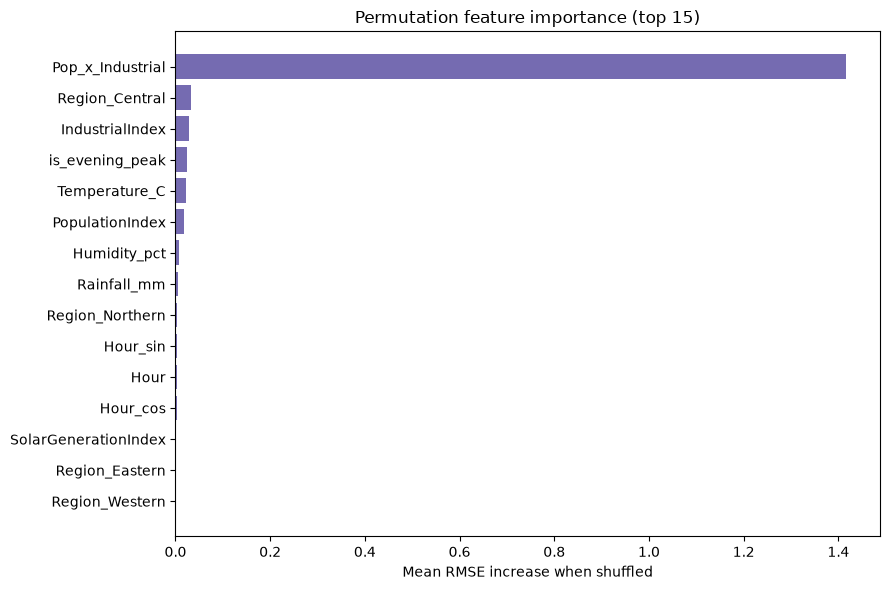

In [3]:
top = imp.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top.index, top.values, color='#756bb1')
ax.set_xlabel('Mean RMSE increase when shuffled')
ax.set_title('Permutation feature importance (top 15)')
fig.tight_layout(); fig.savefig(FIGURES_DIR / 'feature_importance.png', dpi=120)
plt.show()

## Native importance (if the model exposes it)

In [4]:
est = model.named_steps['model'] if hasattr(model, 'named_steps') else model
if hasattr(est, 'feature_importances_'):
    native = pd.Series(est.feature_importances_, index=X.columns).sort_values(ascending=False)
    display(native.head(15).to_frame('impurity_importance'))
else:
    print('Model has no native feature_importances_; rely on permutation importance above.')

,impurity_importance
Pop_x_Industrial,0.899866
IndustrialIndex,0.022664
Region_Central,0.021127
is_evening_peak,0.014703
PopulationIndex,0.012375
Temperature_C,0.010645
Humidity_pct,0.004322
Hour_sin,0.002846
Region_Northern,0.002717
Hour_cos,0.002681


## Insights
- The top-ranked features are the levers that most move predicted grid load.
- Population/industrial indices and temperature dominating would confirm the EDA correlation story; cyclical hour features ranking high confirms the daily load curve.
- **Recommendation:** prioritise accurate, timely collection of the top drivers; the model degrades most when those inputs are missing or stale.